# Experimentation Module Demo

This notebook demonstrates the `Experiment` class from `skfair.experimentation`, which automates fairness-aware ML experiments.

| Section | What it covers |
|---------|---------------|
| **A** | XML-based workflow — load config, run, plot, audit |
| **B** | Pure Python API — configure everything in code |
| **C** | Customization — override datasets, methods, splits |
| **D** | Available registries — datasets, methods, metrics |

In [1]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

from skfair.experimentation import Experiment

---
## Section A: XML-based workflow

The simplest way to run an experiment is to define everything in an XML file and load it.

In [2]:
exp = Experiment.from_xml("experiment_config.xml")

print(f"Datasets:    {exp.datasets}")
print(f"Methods:     {exp.methods}")
print(f"Classifiers: {list(exp.classifiers.keys())}")
print(f"Metrics:     {exp.metrics}")
print(f"CV folds:    {exp.n_splits}")

Datasets:    ['ricci']
Methods:     ['Baseline', 'FairSmote', 'Massaging', 'FairOversampling', 'FAWOS', 'HeterogeneousFOS', 'FairwayRemover', 'GeometricFairnessRepair', 'LearningFairRepresentations', 'ReweighingClassifier', 'FairBalanceClassifier', 'FairMask']
Classifiers: ['LogisticRegression', 'SVC']
Metrics:     ['accuracy', 'balanced_accuracy', 'disparate_impact', 'spd', 'eod', 'aod']
CV folds:    5


In [3]:
df = exp.run()
print(f"Results shape: {df.shape}  (12 methods x 2 classifiers = 24 rows)")
display(df.head(10))


Dataset: Ricci
  Baseline                       | LogisticRegression  acc=0.812  spd=-0.509
  Baseline                       | SVC  acc=0.914  spd=-0.369
  FairSmote                      | LogisticRegression  acc=0.830  spd=-0.125
  FairSmote                      | SVC  acc=0.923  spd=-0.339
  Massaging                      | LogisticRegression  acc=0.685  spd=0.004
  Massaging                      | SVC  acc=0.863  spd=-0.377
  FairOversampling               | LogisticRegression  acc=0.787  spd=-0.162
  FairOversampling               | SVC  acc=0.889  spd=-0.333
  FAWOS                          | LogisticRegression  acc=0.771  spd=-0.144
  FAWOS                          | SVC  acc=0.872  spd=-0.390
  HeterogeneousFOS               | LogisticRegression  acc=0.864  spd=-0.128
  HeterogeneousFOS               | SVC  acc=0.932  spd=-0.359
  FairwayRemover                 | LogisticRegression  acc=0.525  spd=-0.045
  FairwayRemover                 | SVC  acc=0.652  spd=-0.176
  GeometricF

,dataset,method,classifier,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,disparate_impact_mean,disparate_impact_std,spd_mean,spd_std,eod_mean,eod_std,aod_mean,aod_std
0,Ricci,Baseline,LogisticRegression,0.811594,0.122456,0.811655,0.123102,0.289444,0.115567,-0.509213,0.116894,-0.334524,0.225827,-0.323810,0.212521
1,Ricci,Baseline,SVC,0.914493,0.039713,0.914918,0.040560,0.440101,0.131968,-0.369213,0.108299,-0.079762,0.169182,-0.121429,0.110551
2,Ricci,FairSmote,LogisticRegression,0.829710,0.049665,0.834907,0.052012,0.884608,0.412811,-0.125369,0.288120,0.102143,0.104968,0.076151,0.223208
3,Ricci,FairSmote,SVC,0.922826,0.051452,0.925524,0.050913,0.527955,0.189282,-0.339365,0.172057,0.028571,0.057143,-0.075595,0.108353
4,Ricci,Massaging,LogisticRegression,0.685145,0.092419,0.687587,0.093983,1.031284,0.290206,0.003627,0.160255,0.082381,0.277359,0.132540,0.179292
5,Ricci,Massaging,SVC,0.862681,0.094038,0.862646,0.095533,0.426580,0.123781,-0.377162,0.132065,-0.131190,0.157720,-0.155476,0.157314
6,Ricci,FairOversampling,LogisticRegression,0.787319,0.056834,0.795047,0.056076,0.830303,0.396240,-0.161884,0.302858,0.015476,0.157377,0.010595,0.269700
7,Ricci,FairOversampling,SVC,0.889130,0.059440,0.893473,0.058202,0.556566,0.160483,-0.332527,0.163051,0.028571,0.057143,-0.091865,0.135276
8,Ricci,FAWOS,LogisticRegression,0.770652,0.064779,0.781177,0.059940,0.830707,0.295522,-0.143790,0.234908,0.053571,0.065854,0.032976,0.178988
9,Ricci,FAWOS,SVC,0.872464,0.028726,0.878205,0.028596,0.510716,0.137239,-0.390412,0.155559,0.000000,0.000000,-0.163651,0.133989


### Comparison report plots

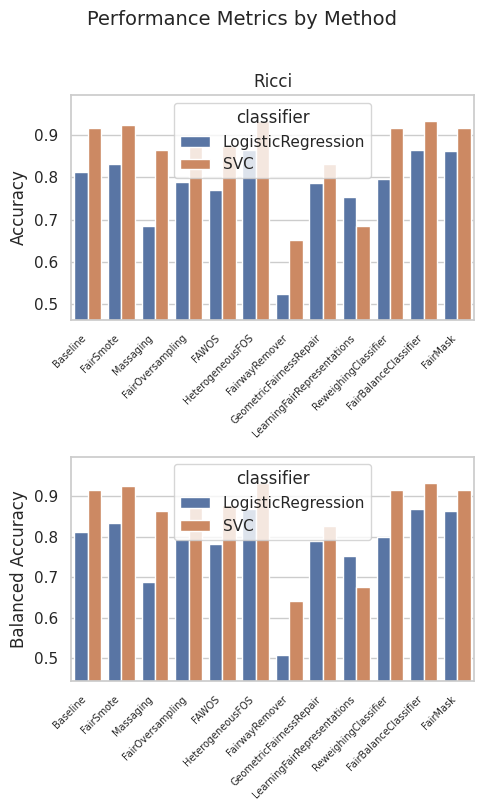

In [4]:
report = exp.to_report()

report.plot_performance()
plt.show()

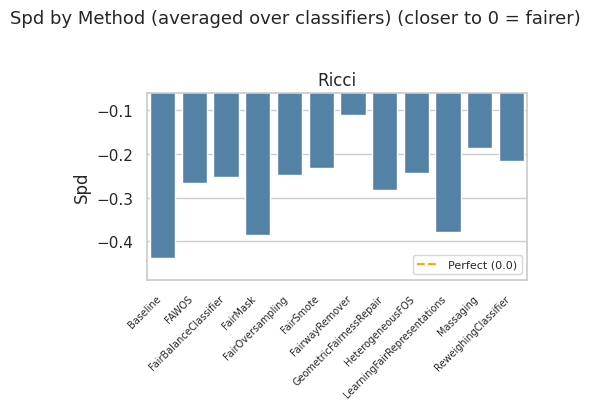

In [5]:
report.plot_fairness_averaged()
plt.show()

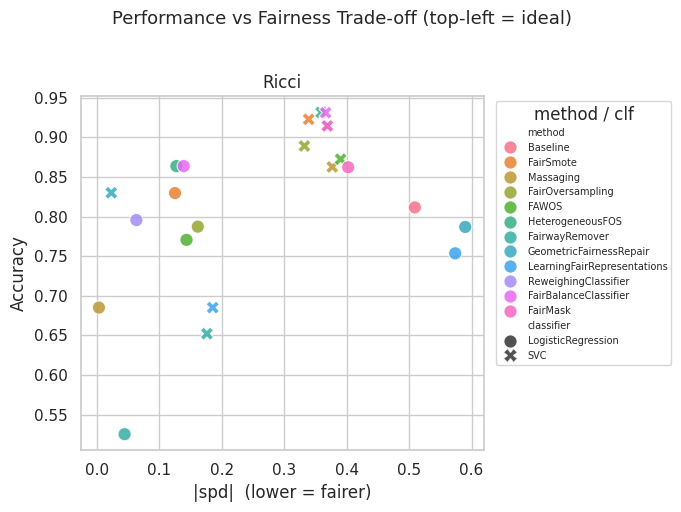

In [6]:
report.plot_tradeoff()
plt.show()

### Fairness audit for a single (dataset, method, classifier) combination

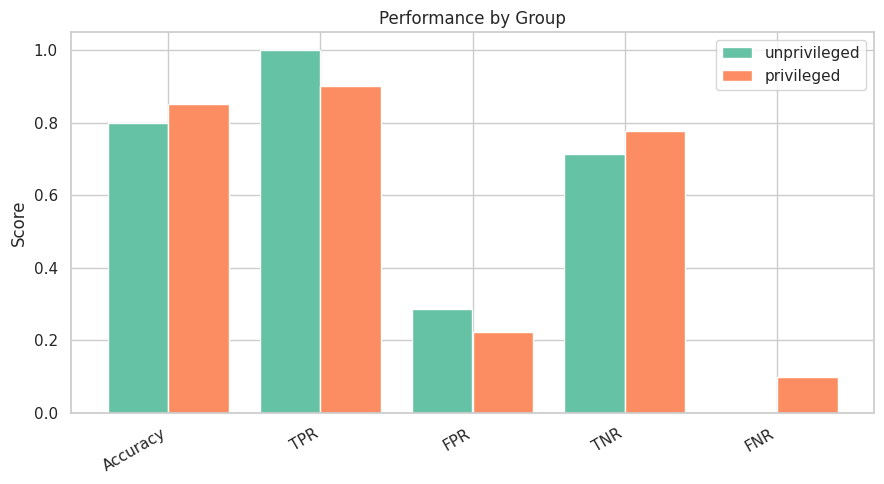

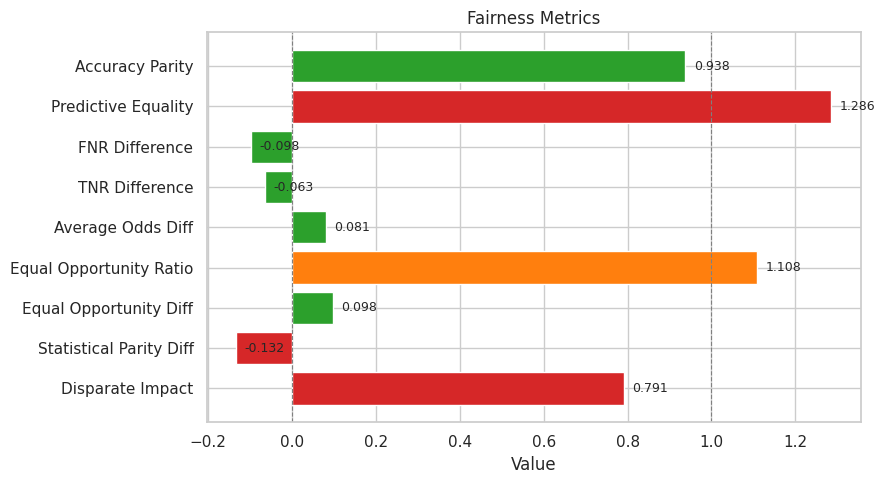

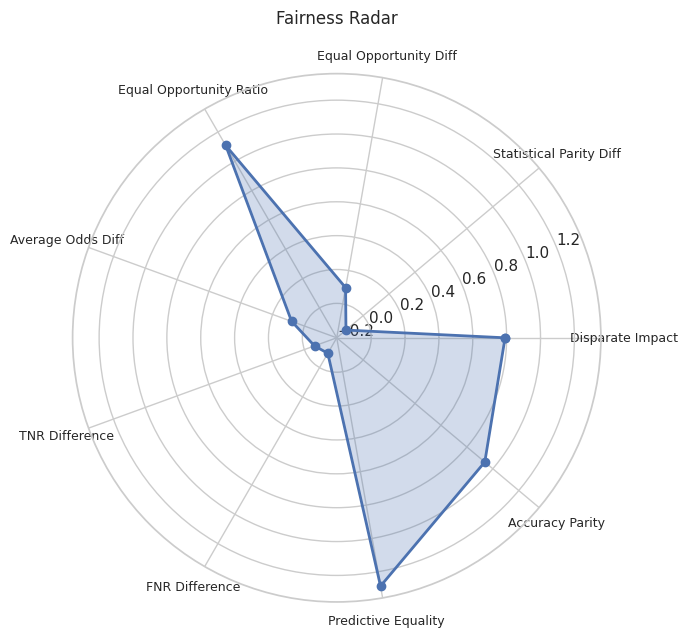

In [7]:
auditor = exp.get_fairness_auditor("Ricci", "FairSmote", "LogisticRegression")
auditor.plot_summary()
plt.show()

### Bias audit (dataset-level)

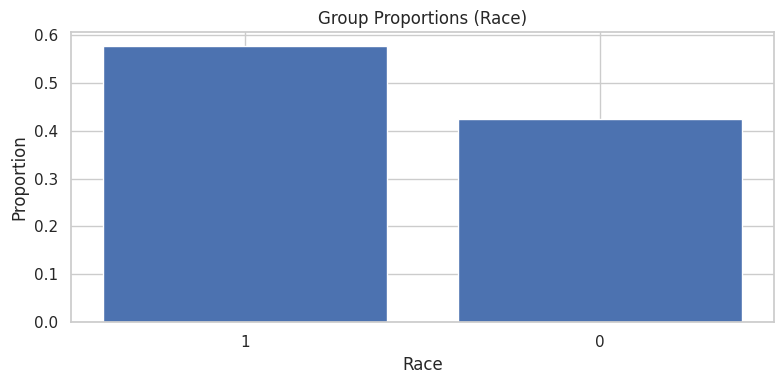

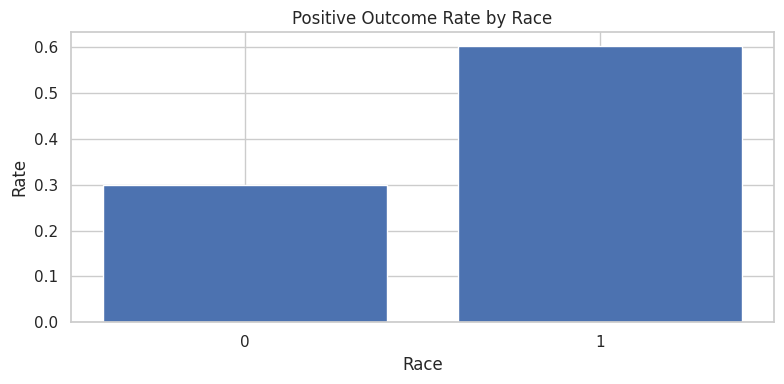

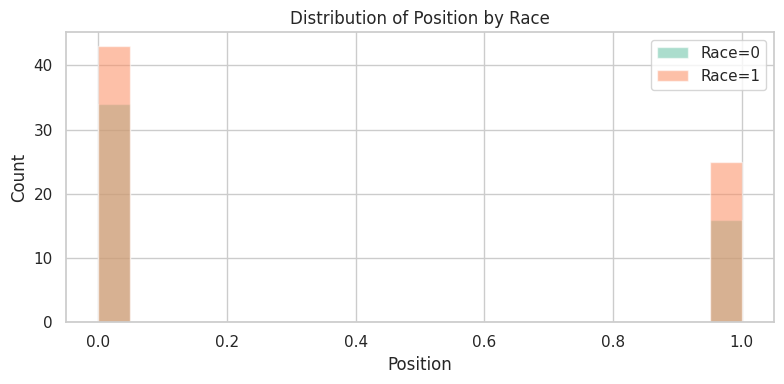

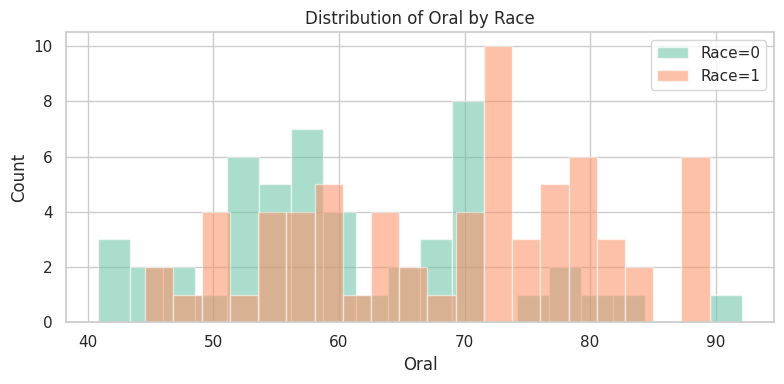

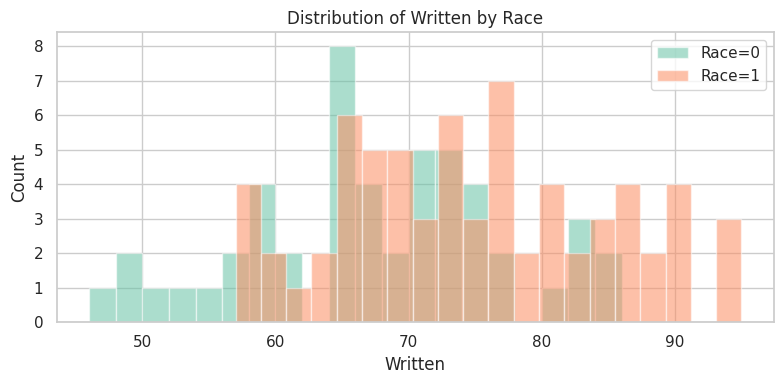

In [8]:
exp.bias_reports_["ricci"].plot_summary()
plt.show()

### Save results

In [9]:
exp.save("results.csv")
print("Results saved to results.csv")

Results saved to results.csv


---
## Section B: Pure Python API

You can configure everything directly in Python without an XML file.

In [10]:
from sklearn.linear_model import LogisticRegression

exp_py = Experiment(
    datasets=["ricci"],
    methods=["Baseline", "FairSmote", "Massaging"],
    classifiers={
        "LogReg": LogisticRegression(solver="liblinear", max_iter=1000, random_state=42),
    },
    audit_fairness=True,
)

df_py = exp_py.run()
display(df_py)


Dataset: Ricci
  Baseline                       | LogReg  acc=0.812  spd=-0.509
  FairSmote                      | LogReg  acc=0.830  spd=-0.125
  Massaging                      | LogReg  acc=0.685  spd=0.004


,dataset,method,classifier,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,disparate_impact_mean,disparate_impact_std,spd_mean,spd_std,eod_mean,eod_std,aod_mean,aod_std
0,Ricci,Baseline,LogReg,0.811594,0.122456,0.811655,0.123102,0.289444,0.115567,-0.509213,0.116894,-0.334524,0.225827,-0.323810,0.212521
1,Ricci,FairSmote,LogReg,0.829710,0.049665,0.834907,0.052012,0.884608,0.412811,-0.125369,0.288120,0.102143,0.104968,0.076151,0.223208
2,Ricci,Massaging,LogReg,0.685145,0.092419,0.687587,0.093983,1.031284,0.290206,0.003627,0.160255,0.082381,0.277359,0.132540,0.179292


In [11]:
report_py = exp_py.to_report()
report_py.summary_tables()

{'Ricci':            accuracy  balanced_accuracy  disparate_impact     spd     eod  \
 method                                                                     
 Baseline     0.8116             0.8117            0.2894 -0.5092 -0.3345   
 FairSmote    0.8297             0.8349            0.8846 -0.1254  0.1021   
 Massaging    0.6851             0.6876            1.0313  0.0036  0.0824   
 
               aod  
 method             
 Baseline  -0.3238  
 FairSmote  0.0762  
 Massaging  0.1325  }

---
## Section C: Customization

Override dataset configuration, method parameters, or number of CV splits.

In [12]:
exp_custom = Experiment(
    datasets=["ricci"],
    methods=["Baseline", "FairSmote"],
    dataset_config={"ricci": {"sens_attr": "Race", "priv_group": 1}},
    method_config={"FairSmote": {"random_state": 0}},
    n_splits=1,
)

df_custom = exp_custom.run()
display(df_custom)


Dataset: Ricci
  Baseline                       | LogReg  acc=0.833  spd=-0.250
  FairSmote                      | LogReg  acc=0.875  spd=-0.167


,dataset,method,classifier,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,disparate_impact_mean,disparate_impact_std,spd_mean,spd_std,eod_mean,eod_std,aod_mean,aod_std
0,Ricci,Baseline,LogReg,0.833333,0.0,0.832168,0.0,0.571429,0.0,-0.250000,0.0,-0.107143,0.0,-0.091071,0.0
1,Ricci,FairSmote,LogReg,0.875000,0.0,0.877622,0.0,0.714286,0.0,-0.166667,0.0,0.142857,0.0,0.033929,0.0


---
## Section D: Available registries

Check which datasets, methods, and metrics are registered.

In [13]:
from skfair.experimentation._registry import DATASET_REGISTRY, METHOD_REGISTRY, METRIC_REGISTRY

print("=== Datasets ===")
for name, info in DATASET_REGISTRY.items():
    print(f"  {name}: sens_attr={info.get('sens_attr')}, priv_group={info.get('priv_group')}")

print("\n=== Methods ===")
for name in METHOD_REGISTRY:
    print(f"  {name}")

print("\n=== Metrics ===")
for name in METRIC_REGISTRY:
    print(f"  {name}")

=== Datasets ===
  adult: sens_attr=sex, priv_group=1
  compas: sens_attr=sex, priv_group=1
  german: sens_attr=sex, priv_group=1
  heart_disease: sens_attr=sex, priv_group=1
  ricci: sens_attr=Race, priv_group=1

=== Methods ===
  Baseline
  Massaging
  FairSmote
  FairOversampling
  FAWOS
  HeterogeneousFOS
  FairwayRemover
  GeometricFairnessRepair
  LearningFairRepresentations
  ReweighingClassifier
  FairBalanceClassifier
  FairMask

=== Metrics ===
  accuracy
  balanced_accuracy
  disparate_impact
  spd
  eod
  aod
